In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# EDA - Visualising Missing Data

In [4]:
carmyllie_hygro = pd.read_csv("../data/Hygro00:90_70B3D51C20000090_365days.csv")

carmyllie_droplet = pd.read_csv("../data/Droplet_2_70B3D5499AFA2DEE_365days.csv")

In [5]:
carmyllie_hygro['timestamp'] = pd.to_datetime(carmyllie_hygro['timestamp'])
carmyllie_hygro['gap'] = carmyllie_hygro['timestamp'].diff().dt.total_seconds() / 60
carmyllie_hygro['gap'].describe()

count    33812.000000
mean        15.544409
std          2.563907
min         15.099617
25%         15.175946
50%         15.176121
75%         15.176321
max         75.879514
Name: gap, dtype: float64

In [6]:
carmyllie_droplet['timestamp'] = pd.to_datetime(carmyllie_droplet['timestamp'])
carmyllie_droplet['gap'] = carmyllie_droplet['timestamp'].diff().dt.total_seconds() / 60
carmyllie_droplet['gap'].describe()

count    31366.000000
mean        16.756581
std          6.327820
min         15.269347
25%         15.348496
50%         15.473182
75%         15.667711
max        250.934608
Name: gap, dtype: float64

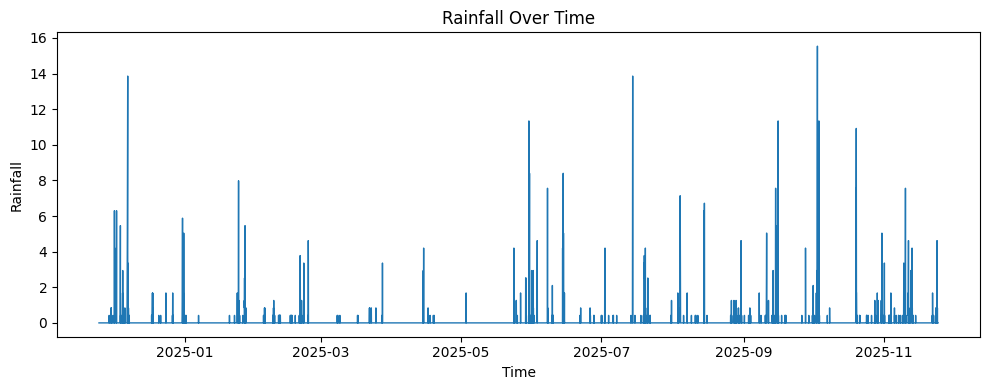

In [7]:
def plot_variable_over_time( df, variable, time_col="timestamp", title=None,figsize=(10,4)):
    """
    Plots any numeric variable against time.
    """

    # Ensure sorted by time
    df = df.sort_values(time_col)

    plt.figure(figsize=figsize)
    plt.plot(df[time_col], df[variable], label=variable, linewidth=1)

    plt.xlabel("Time")
    plt.ylabel(variable.replace("_", " ").title())
    plt.title(title if title else f"{variable.replace('_',' ').title()} Over Time")
    # plt.legend()

    plt.tight_layout()
    plt.show()

plot_variable_over_time(carmyllie_droplet[carmyllie_droplet.rainfall<1000], "rainfall")

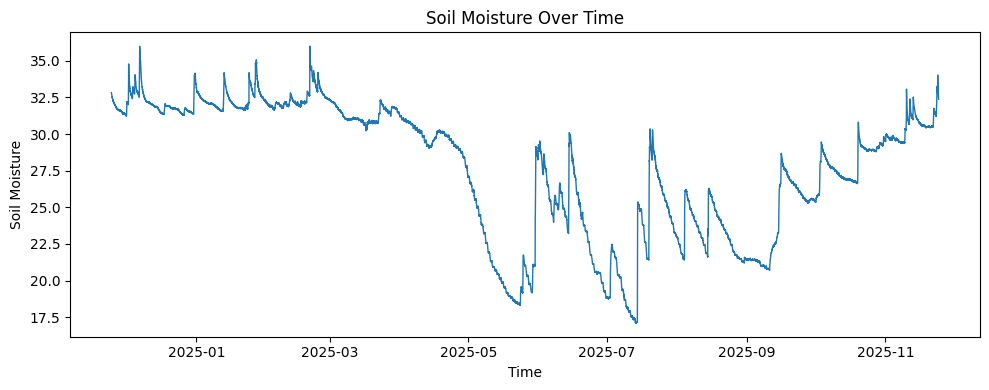

In [8]:
plot_variable_over_time(carmyllie_hygro, "soil_moisture")

In [9]:
sum(carmyllie_droplet.rainfall>0)/carmyllie_droplet.shape[0]*100

2.059489272165014

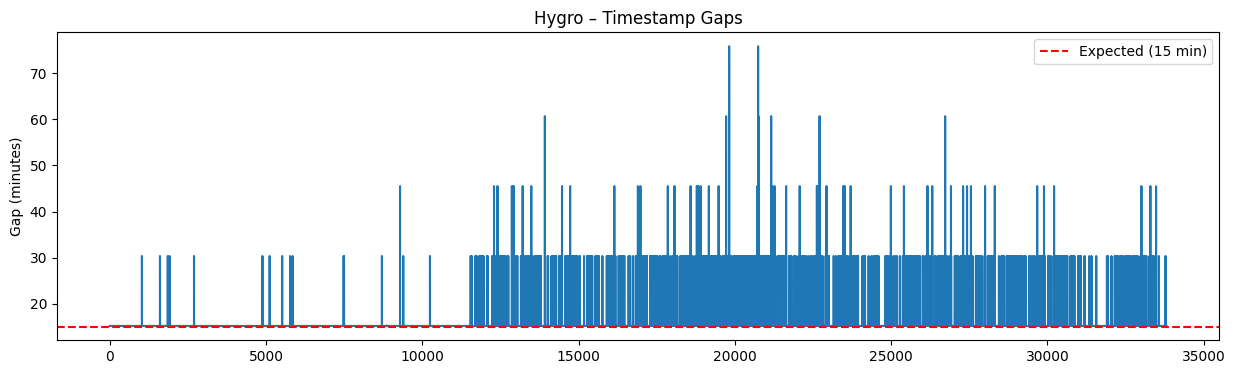

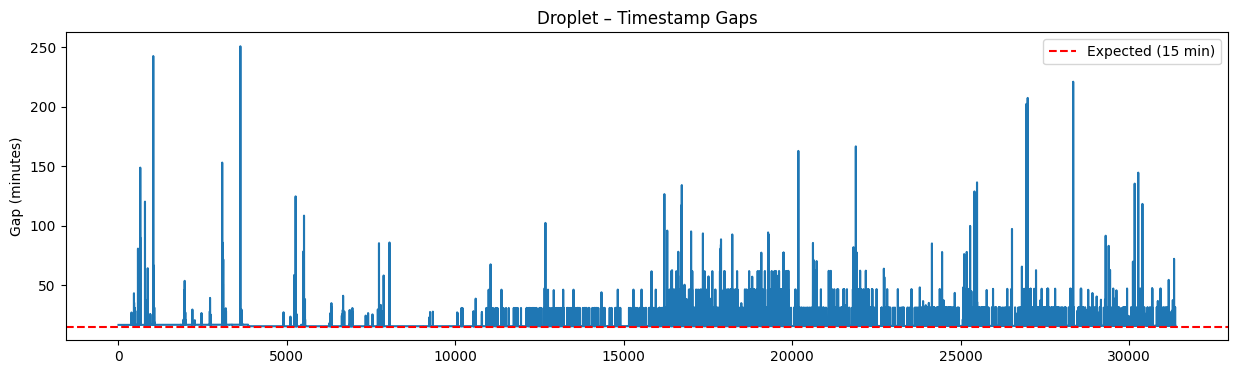

In [10]:
def plot_time_gaps(df, title):
    ts = df.set_index("timestamp").sort_index()
    dt = ts.index.to_series().diff().dt.total_seconds() / 60  # minutes
    
    plt.figure(figsize=(15,4))
    plt.plot(dt.values)
    plt.axhline(15, color="red", linestyle="--", label="Expected (15 min)")
    plt.title(title)
    plt.ylabel("Gap (minutes)")
    plt.legend()
    plt.show()

plot_time_gaps(carmyllie_hygro, "Hygro – Timestamp Gaps")
plot_time_gaps(carmyllie_droplet, "Droplet – Timestamp Gaps")

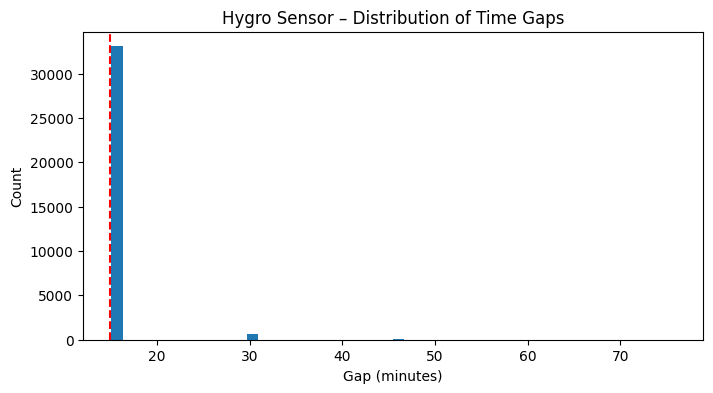

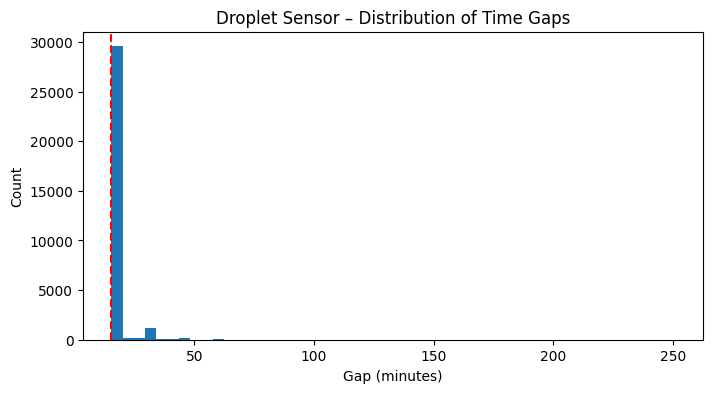

In [11]:
def hist_time_gaps(df, label):
    gaps = df.sort_values("timestamp")["timestamp"].diff().dt.total_seconds() / 60

    plt.figure(figsize=(8,4))
    plt.hist(gaps.dropna(), bins=50)
    plt.axvline(15, color="red", linestyle="--")
    plt.title(f"{label} – Distribution of Time Gaps")
    plt.xlabel("Gap (minutes)")
    plt.ylabel("Count")
    plt.show()

hist_time_gaps(carmyllie_hygro, "Hygro Sensor")
hist_time_gaps(carmyllie_droplet, "Droplet Sensor")

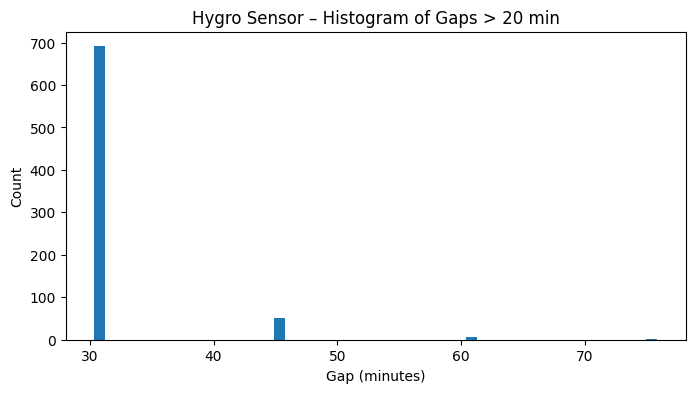

Hygro Sensor: Number of gaps > 20 minutes = 751
Min gap > 20: 30.3 min
Max gap > 20: 75.9 min
Median gap > 20: 30.4 min


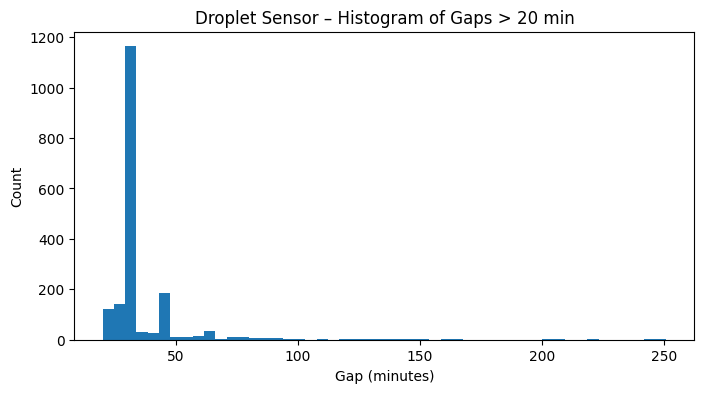

Droplet Sensor: Number of gaps > 20 minutes = 1805
Min gap > 20: 20.0 min
Max gap > 20: 250.9 min
Median gap > 20: 31.0 min


In [12]:
def hist_large_gaps(df, label, threshold=20):
    # Compute gaps in minutes
    gaps = (
        df.sort_values("timestamp")["timestamp"]
        .diff()
        .dt.total_seconds() / 60
    )

    # Filter only large gaps
    large_gaps = gaps[gaps > threshold]

    plt.figure(figsize=(8,4))
    plt.hist(large_gaps, bins=50)
    plt.title(f"{label} – Histogram of Gaps > {threshold} min")
    plt.xlabel("Gap (minutes)")
    plt.ylabel("Count")
    plt.show()

    print(f"{label}: Number of gaps > {threshold} minutes = {len(large_gaps)}")
    print(f"Min gap > {threshold}: {large_gaps.min():.1f} min")
    print(f"Max gap > {threshold}: {large_gaps.max():.1f} min")
    print(f"Median gap > {threshold}: {large_gaps.median():.1f} min")

hist_large_gaps(carmyllie_hygro, "Hygro Sensor")
hist_large_gaps(carmyllie_droplet, "Droplet Sensor")

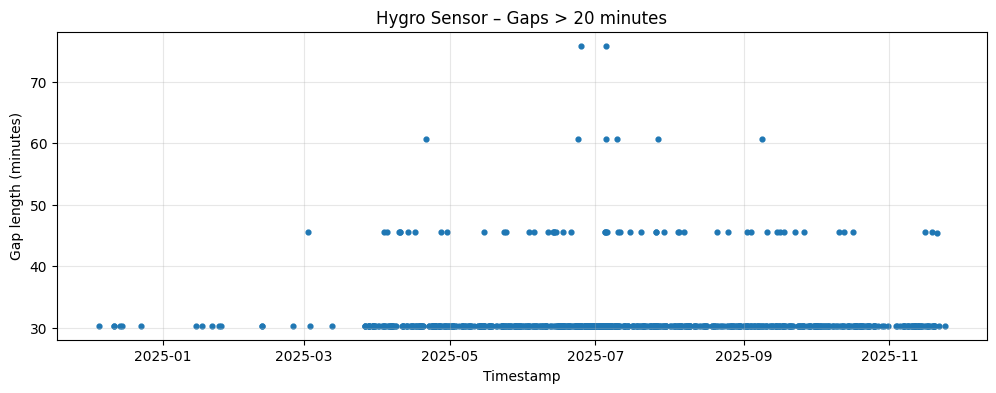

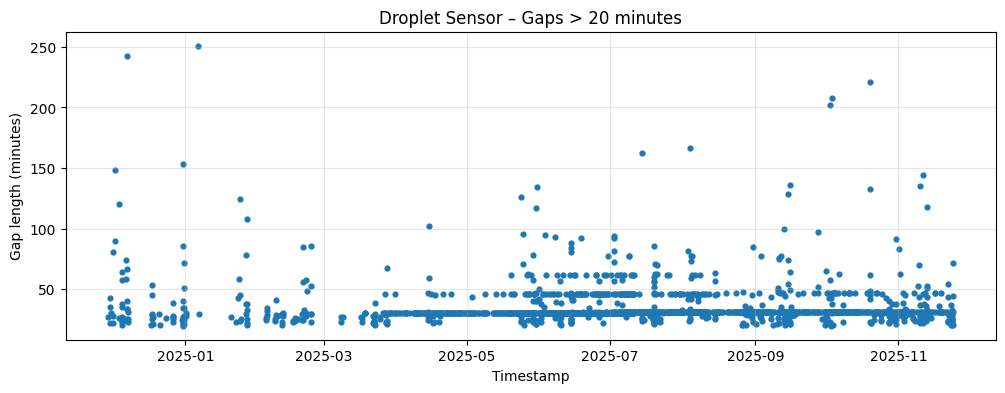

In [13]:
def scatter_large_gaps(df, label, threshold=20):
    # Compute gaps
    df_sorted = df.sort_values("timestamp")
    gaps = df_sorted["timestamp"].diff().dt.total_seconds() / 60

    # Keep only > threshold
    large_gaps = gaps[gaps > threshold]
    large_times = df_sorted["timestamp"].iloc[large_gaps.index]

    plt.figure(figsize=(12,4))
    plt.scatter(large_times, large_gaps, s=12)
    plt.title(f"{label} – Gaps > {threshold} minutes")
    plt.xlabel("Timestamp")
    plt.ylabel("Gap length (minutes)")
    plt.grid(True, alpha=0.3)
    plt.show()

scatter_large_gaps(carmyllie_hygro, "Hygro Sensor")
scatter_large_gaps(carmyllie_droplet, "Droplet Sensor")

/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_93094/873947911.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


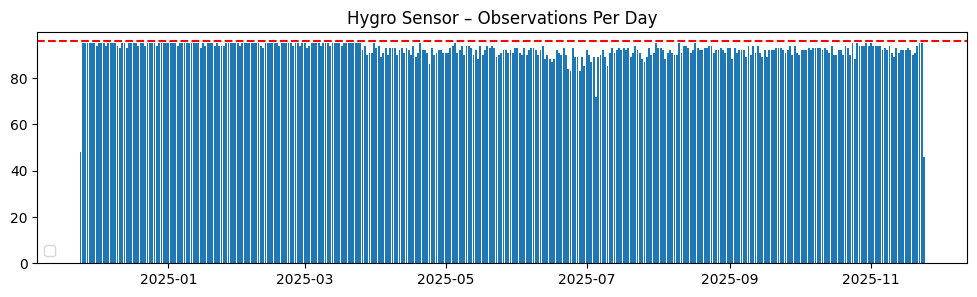

/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_93094/873947911.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


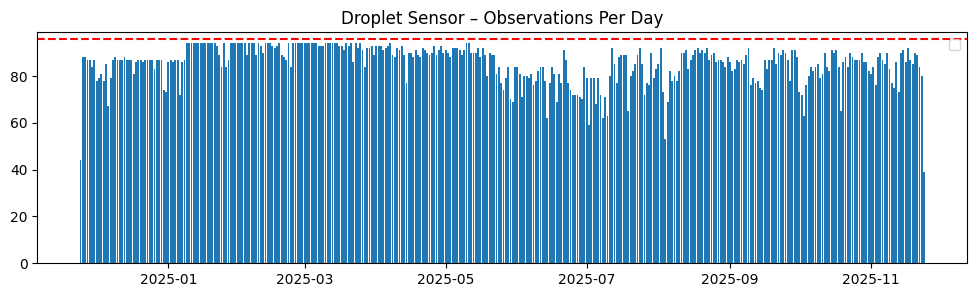

In [14]:
def plot_daily_counts(df, label):
    ts = df.set_index("timestamp").sort_index()
    counts = ts.resample("D").size()

    plt.figure(figsize=(12,3))
    plt.bar(counts.index, counts.values)
    plt.axhline(24*4, color="red", linestyle="--")
    plt.title(f"{label} – Observations Per Day")
    plt.legend()
    plt.show()

plot_daily_counts(carmyllie_hygro, "Hygro Sensor")
plot_daily_counts(carmyllie_droplet, "Droplet Sensor")

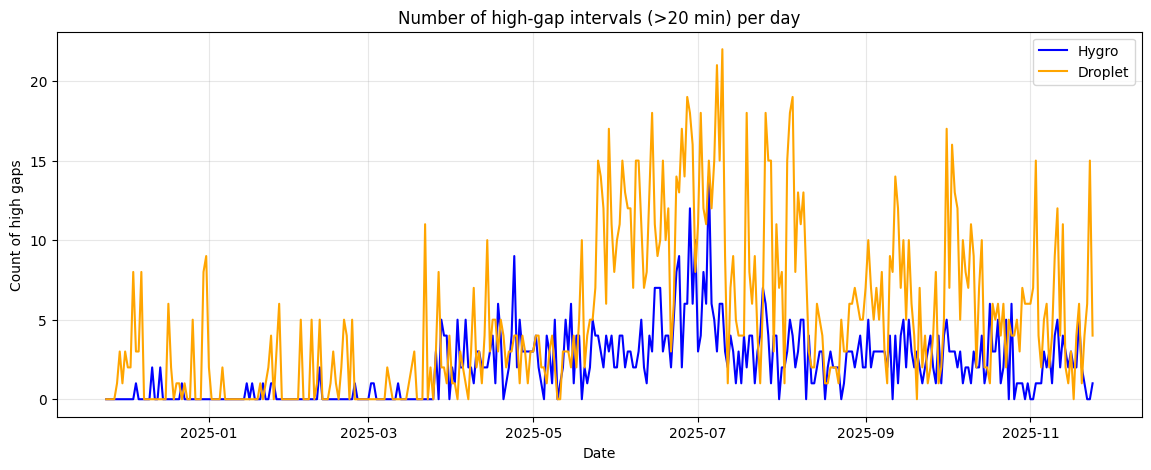

In [15]:
def daily_high_gap_counts(df, sensor_name, threshold=20):
    df_sorted = df.sort_values("timestamp").copy()
    
    # Compute gaps in minutes
    df_sorted["gap_min"] = df_sorted["timestamp"].diff().dt.total_seconds() / 60
    
    # Flag gaps > threshold
    df_sorted["high_gap"] = (df_sorted["gap_min"] > threshold).astype(int)
    
    # Aggregate per day
    df_sorted["date"] = df_sorted["timestamp"].dt.date
    daily_counts = df_sorted.groupby("date")["high_gap"].sum()
    
    return daily_counts.rename(sensor_name)

hygro_counts = daily_high_gap_counts(carmyllie_hygro, "Hygro")
droplet_counts = daily_high_gap_counts(carmyllie_droplet, "Droplet")

combined_counts = pd.concat([hygro_counts, droplet_counts], axis=1).fillna(0)

# Plot
plt.figure(figsize=(14,5))
plt.plot(combined_counts.index, combined_counts["Hygro"], label="Hygro", color="blue")
plt.plot(combined_counts.index, combined_counts["Droplet"], label="Droplet", color="orange")
plt.title("Number of high-gap intervals (>20 min) per day")
plt.xlabel("Date")
plt.ylabel("Count of high gaps")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Heatmaps to observe whether there is correlation between missing data and the features

In [16]:
carmyllie_hygro = carmyllie_hygro.drop(columns =["latitude","longitude"])
carmyllie_droplet= carmyllie_droplet.drop(columns =["latitude","longitude","rtc_temp"])

In [17]:
def missing_feature_correlation(df, threshold=16):
    df_sorted = df.sort_values("timestamp").copy()
    df_sorted["missing_flag"] = (df_sorted["gap"] > threshold).astype(int)

    # Select numeric columns
    numeric_cols = df_sorted.select_dtypes(include="number").columns.tolist()

    # Add missing_flag to numeric features
    corr_df = df_sorted[numeric_cols].copy()

    # Compute correlation
    corr = corr_df.corr()

    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title(f"Feature Correlation (Missingness: gap > {threshold} min)")
    plt.show()

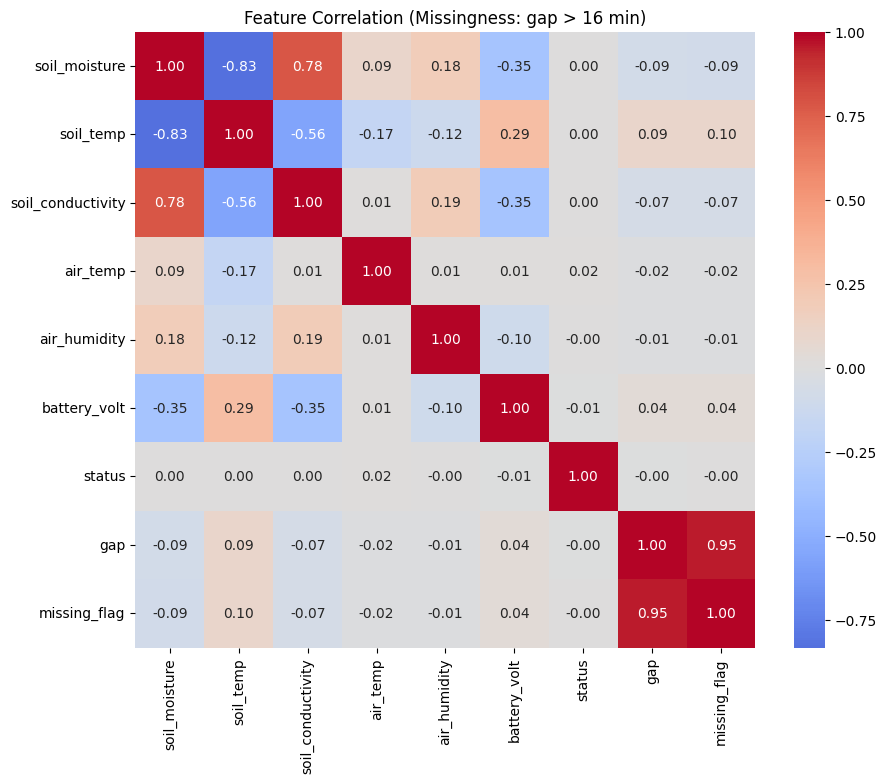

In [18]:
missing_feature_correlation(carmyllie_hygro)

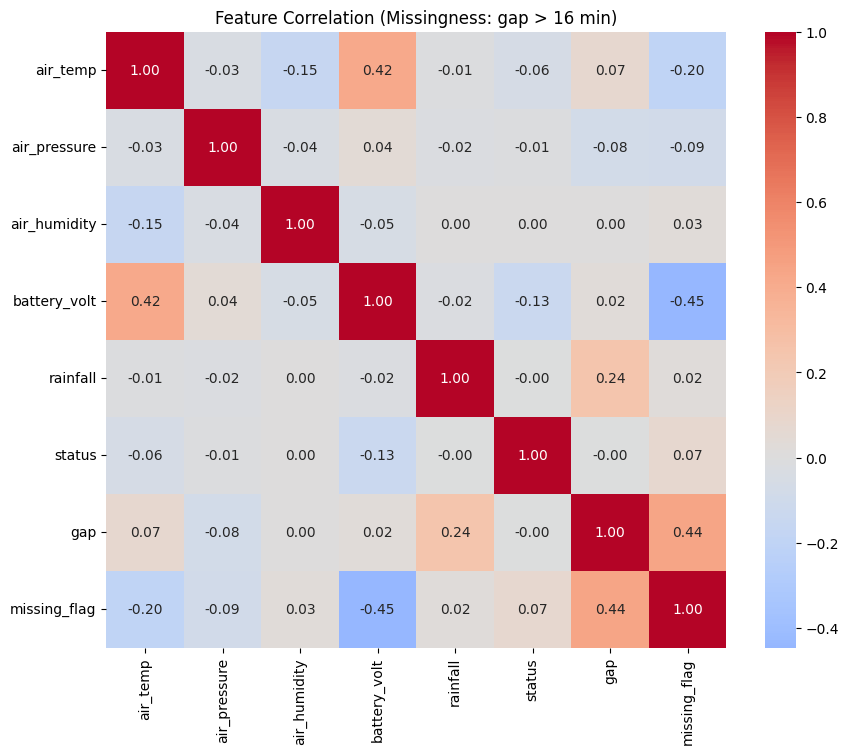

In [19]:
missing_feature_correlation(carmyllie_droplet)

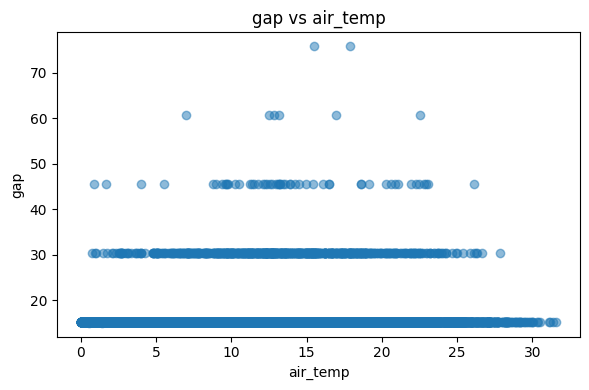

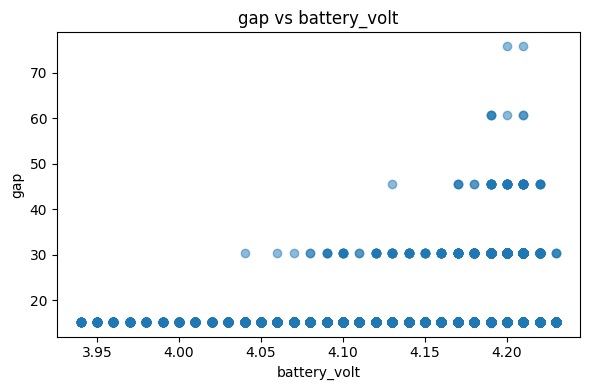

In [20]:
def plot_gap_vs_variable(df, var, gap_col="gap"):
    """
    Plot a scatterplot of gap_minutes vs one selected variable.
    """
    plt.figure(figsize=(6,4))
    plt.scatter(df[var], df[gap_col], alpha=0.5)
    plt.xlabel(var)
    plt.ylabel(gap_col)
    plt.title(f"{gap_col} vs {var}")
    plt.tight_layout()
    plt.show()

plot_gap_vs_variable(carmyllie_hygro[carmyllie_hygro.air_temp<500], "air_temp")
plot_gap_vs_variable(carmyllie_hygro, "battery_volt")

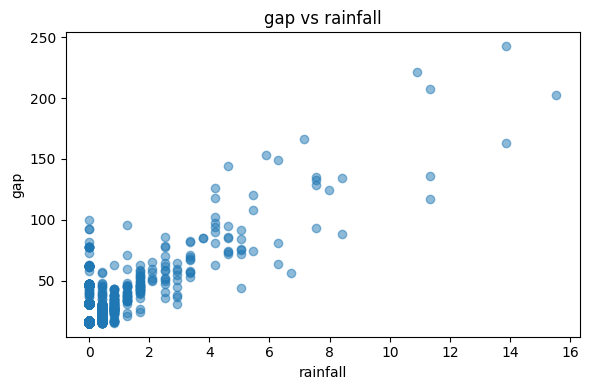

In [21]:
plot_gap_vs_variable(carmyllie_droplet[carmyllie_droplet.rainfall<1000], "rainfall")

<Figure size 600x400 with 0 Axes>

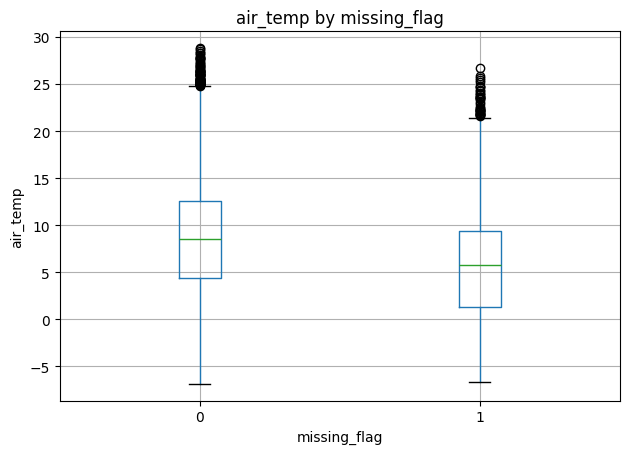

<Figure size 600x400 with 0 Axes>

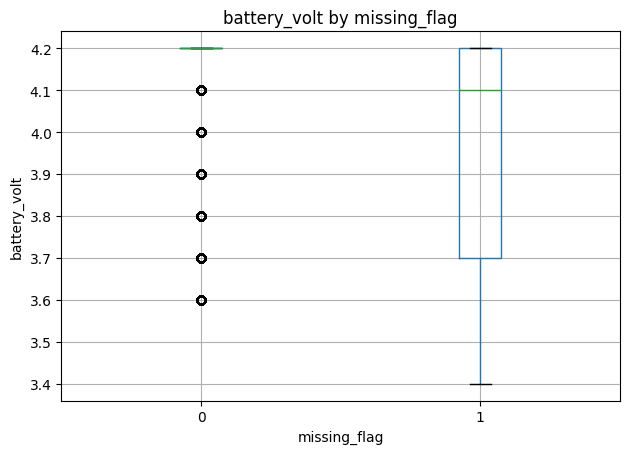

In [22]:
def plot_variable_by_missingflag(df, var, flag_col="missing_flag"):
    """
    Boxplot of selected variable grouped by missing_flag (0 vs 1).
    """
    df_sorted = df.sort_values("timestamp").copy()
    df_sorted["missing_flag"] = (df_sorted["gap"] > 16).astype(int)

    plt.figure(figsize=(6,4))
    df_sorted.boxplot(column=var, by=flag_col)
    plt.title(f"{var} by {flag_col}")
    plt.suptitle("")
    plt.xlabel(flag_col)
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

plot_variable_by_missingflag(carmyllie_droplet, "air_temp")
plot_variable_by_missingflag(carmyllie_droplet, "battery_volt")

<Figure size 600x400 with 0 Axes>

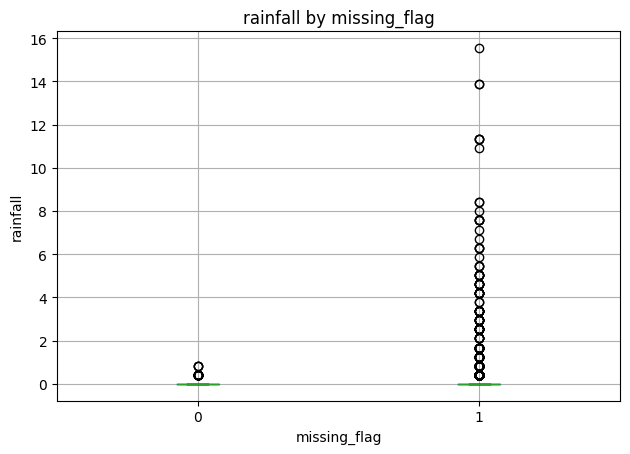

In [23]:
plot_variable_by_missingflag(carmyllie_droplet[carmyllie_droplet.rainfall<1000], "rainfall")

In [24]:
carmyllie_droplet

,timestamp,device_eui,device_name,device_type,site_name,payload,air_temp,air_pressure,air_humidity,battery_volt,rainfall,status,gap
0,2024-11-24 12:00:39.641642+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,02d80001761a27100029000000000000,7.28,957.70,100.0,4.1,0.0,0.0,NaN
1,2024-11-24 12:17:05.110090+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,02d60001760e2710002a000000000000,7.26,957.58,100.0,4.2,0.0,0.0,16.424474
2,2024-11-24 12:33:30.805474+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,02ee000176202710002a000000000000,7.50,957.76,100.0,4.2,0.0,0.0,16.428256
3,2024-11-24 12:49:56.926009+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,03140001762227100029000000000000,7.88,957.78,100.0,4.1,0.0,0.0,16.435342
4,2024-11-24 13:06:22.809756+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,0322000175ff2710002a000000000000,8.02,957.43,100.0,4.2,0.0,0.0,16.431396
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31362,2025-11-24 10:44:41.087356+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,01fa00017dd927100028000000000000,5.06,977.53,100.0,4.0,0.0,0.0,15.743631
31363,2025-11-24 11:00:25.214934+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,023a00017dfb27100029000000000000,5.70,977.87,100.0,4.1,0.0,0.0,15.735460
31364,2025-11-24 11:16:07.576291+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,01f900017e0d27100028000000000000,5.05,978.05,100.0,4.0,0.0,0.0,15.706023
31365,2025-11-24 11:31:51.098210+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,01d700017e5227100029000000000000,4.71,978.74,100.0,4.1,0.0,0.0,15.725365


## Merging Train and Test Datasets

### Train

In [25]:
# 1) Define shared start and end times
start = max(carmyllie_hygro["timestamp"].min(),
            carmyllie_droplet["timestamp"].min())

end = min(carmyllie_hygro["timestamp"].max(),
          carmyllie_droplet["timestamp"].max())

# Force a shared 15-minute regular grid
grid = pd.DataFrame({
    "timestamp": pd.date_range(start=start, end=end, freq="15min")
})

def align_sensor_to_grid(sensor_df, grid, freq="15min"):
    df = sensor_df.sort_values("timestamp").copy()
    df = df.rename(columns={"timestamp": "actual_timestamp"})  # keep original timestamp

    # Create a fabricated timestamp column for alignment
    df["timestamp"] = df["actual_timestamp"]

    # tolerance = half the grid frequency
    tol = pd.Timedelta(freq) / 2
    aligned = pd.merge_asof(
        grid, df,
        on="timestamp",
        direction="nearest",
        tolerance=tol,
        allow_exact_matches=False
    )

    return aligned

hygro_aligned = align_sensor_to_grid(carmyllie_hygro, grid, "15min")
droplet_aligned = align_sensor_to_grid(carmyllie_droplet, grid, "15min")

In [26]:
hygro_merge = hygro_aligned.drop(columns=["device_eui", "device_name", "device_type", "site_name", "payload", "status", "gap"])
droplet_merge = droplet_aligned.drop(columns=["device_name","device_eui","device_type","site_name","payload","status", "gap"])

In [27]:
def align_to_15min(ts):
    """
    Align a timestamp to the nearest previous 15-minute mark.
    """
    # Floor to nearest 15 minutes
    return ts.floor('15T')

hygro_merge['timestamp'] = hygro_merge['timestamp'].dt.tz_convert(None).apply(align_to_15min)
droplet_merge['timestamp'] = droplet_merge['timestamp'].dt.tz_convert(None).apply(align_to_15min)

/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_93094/1909181431.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  return ts.floor('15T')
/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_93094/1909181431.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  return ts.floor('15T')


In [28]:
def interpolate_dataframe(df, timestamp_col="timestamp"):

    df_interp = df.copy()

    # Ensure timestamp is datetime
    df_interp[timestamp_col] = pd.to_datetime(df_interp[timestamp_col])

    # Set index for time-based interpolation
    df_interp = df_interp.set_index(timestamp_col)

    # Interpolate ONLY numeric columns, column-by-column
    for col in df_interp.select_dtypes(include=[np.number]).columns:
        df_interp[col] = df_interp[col].interpolate(
            method="time",
            limit_direction="both"
        )

    # Restore timestamp column
    df_interp = df_interp.reset_index()

    return df_interp

In [29]:
hygro_merge_interp = interpolate_dataframe(hygro_merge, timestamp_col="timestamp")
droplet_merge_interp = interpolate_dataframe(droplet_merge, timestamp_col="timestamp")

In [30]:
droplet_merge[droplet_merge.rainfall>100]

,timestamp,actual_timestamp,air_temp,air_pressure,air_humidity,battery_volt,rainfall
4121,2025-01-06 10:15:00,2025-01-06 10:10:21.762094+00:00,0.26,959.47,100.0,3.6,1042.44


In [31]:
droplet_merge[4080:4130]

,timestamp,actual_timestamp,air_temp,air_pressure,air_humidity,battery_volt,rainfall
4080,2025-01-06 00:00:00,2025-01-05 23:54:03.131800+00:00,-1.01,963.79,100.0,3.7,0.00
4081,2025-01-06 00:15:00,2025-01-06 00:10:39.823345+00:00,-0.96,964.00,100.0,3.6,0.00
4082,2025-01-06 00:30:00,2025-01-06 00:27:16.495855+00:00,-1.00,963.55,100.0,3.7,0.00
4083,2025-01-06 00:45:00,2025-01-06 00:43:52.667021+00:00,-0.93,963.71,100.0,3.7,0.00
4084,2025-01-06 01:00:00,2025-01-06 01:00:29.450295+00:00,-0.97,962.99,100.0,3.6,0.00
4085,2025-01-06 01:15:00,2025-01-06 01:17:05.737423+00:00,-0.94,963.13,100.0,3.7,0.00
4086,2025-01-06 01:30:00,2025-01-06 01:33:42.054042+00:00,-0.98,962.93,100.0,3.6,0.00
4087,2025-01-06 01:45:00,2025-01-06 01:50:18.836006+00:00,-0.97,963.08,100.0,3.7,0.00
4088,2025-01-06 02:00:00,2025-01-06 02:06:55.096747+00:00,-1.00,962.64,100.0,3.6,0.00
4089,2025-01-06 02:15:00,NaT,NaN,NaN,NaN,NaN,NaN


In [32]:
merged_df = pd.merge(
    hygro_merge_interp,
    droplet_merge_interp,
    on="timestamp",
    suffixes=("_hygro", "_droplet")
)

merged_df.to_csv("../data/final_dataset.csv", index=False)

### Test

In [33]:
carmyllie_hygro_test = pd.read_csv("../data/training_data_hygro.csv")
carmyllie_droplet_test = pd.read_csv("../data/training_data_droplet.csv")

carmyllie_hygro_test['timestamp'] = pd.to_datetime(carmyllie_hygro_test['timestamp'])
carmyllie_droplet_test['timestamp'] = pd.to_datetime(carmyllie_droplet_test['timestamp'])

In [34]:
start_test = max(carmyllie_hygro_test["timestamp"].min(),
          carmyllie_droplet_test["timestamp"].min())
end_test = min(carmyllie_hygro_test["timestamp"].max(),
          carmyllie_droplet_test["timestamp"].max())

In [35]:
grid_test = pd.DataFrame({
    "timestamp": pd.date_range(start=start_test, end=end_test, freq="15min")
})

hygro_aligned_test = align_sensor_to_grid(carmyllie_hygro_test, grid_test, "15min")
droplet_aligned_test = align_sensor_to_grid(carmyllie_droplet_test, grid_test, "15min")

In [36]:
hygro_aligned_test['timestamp'] = hygro_aligned_test['timestamp'].dt.tz_convert(None).apply(align_to_15min)
droplet_aligned_test['timestamp'] = droplet_aligned_test['timestamp'].dt.tz_convert(None).apply(align_to_15min)

/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_93094/1909181431.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  return ts.floor('15T')
/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_93094/1909181431.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  return ts.floor('15T')


In [37]:
hygro_merge_test = hygro_aligned_test.drop(columns=["device_eui", "device_name", "device_type", "site_name", "payload", "status", "metadata", "longitude", "latitude"])
droplet_merge_test = droplet_aligned_test.drop(columns=["device_name","device_eui","device_type","site_name","payload","status", "metadata", "longitude", "latitude", "rtc_temp"])

hygro_merge_test_interp = interpolate_dataframe(hygro_merge_test, timestamp_col="timestamp")
droplet_merge_test_interp = interpolate_dataframe(droplet_merge_test, timestamp_col="timestamp")

In [38]:
merged_df_test = pd.merge(
    hygro_merge_test_interp,
    droplet_merge_test_interp,
    on="timestamp",
    suffixes=("_hygro", "_droplet")
)

merged_df_test.to_csv("../data/final_dataset_test.csv", index=False)

In [39]:
carmyllie_hygro_test

,timestamp,device_eui,device_name,device_type,site_name,latitude,longitude,payload,soil_moisture,soil_temp,soil_conductivity,air_temp,air_humidity,battery_volt,status,metadata
0,2024-11-24 11:55:09.904215+00:00,70B3D51C20000090,Hygro#00:90,Hygro,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,6719019a005803b82710107700a1,32.82,4.1,88.0,9.52,100.0,4.21,161.0,NaN
1,2024-11-24 12:10:20.467553+00:00,70B3D51C20000090,Hygro#00:90,Hygro,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,6717019a005803892710107000a2,32.81,4.1,88.0,9.05,100.0,4.21,162.0,NaN
2,2024-11-24 12:25:31.038535+00:00,70B3D51C20000090,Hygro#00:90,Hygro,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,6715019a005803852710107200a3,32.80,4.1,88.0,9.01,100.0,4.21,163.0,NaN
3,2024-11-24 12:40:41.602923+00:00,70B3D51C20000090,Hygro#00:90,Hygro,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,6711019a005903a92710107700a4,32.79,4.1,89.0,9.37,100.0,4.21,164.0,NaN
4,2024-11-24 12:55:52.164092+00:00,70B3D51C20000090,Hygro#00:90,Hygro,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,670f019a005804082710107700a5,32.78,4.1,88.0,10.32,100.0,4.21,165.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35768,2025-12-15 10:17:40.920550097+00:00,70B3D51C20000090,Hygro#00:90,Hygro,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,65c702d0003d027627100f4500ad,31.51,7.2,61.0,6.30,100.0,3.91,173.0,NaN
35769,2025-12-15 10:32:51.494553362+00:00,70B3D51C20000090,Hygro#00:90,Hygro,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,65c502d0003d027127100f4100ae,31.50,7.2,61.0,6.25,100.0,3.90,174.0,NaN
35770,2025-12-15 10:48:02.062399729+00:00,70B3D51C20000090,Hygro#00:90,Hygro,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,65c602c6003d026f27100f4100af,31.50,7.1,61.0,6.23,100.0,3.90,175.0,NaN
35771,2025-12-15 11:03:12.641071022+00:00,70B3D51C20000090,Hygro#00:90,Hygro,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,65c202c6003d026e27100f4100b0,31.49,7.1,61.0,6.22,100.0,3.90,176.0,NaN


In [40]:
carmyllie_droplet_test

,timestamp,device_eui,device_name,device_type,site_name,latitude,longitude,payload,air_temp,air_pressure,air_humidity,battery_volt,rtc_temp,rainfall,status,metadata
0,2024-11-24 12:00:39.641642+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,02d80001761a27100029000000000000,7.28,957.70,100.0,4.1,0.0,0.0,0.0,NaN
1,2024-11-24 12:17:05.110090+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,02d60001760e2710002a000000000000,7.26,957.58,100.0,4.2,0.0,0.0,0.0,NaN
2,2024-11-24 12:33:30.805474+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,02ee000176202710002a000000000000,7.50,957.76,100.0,4.2,0.0,0.0,0.0,NaN
3,2024-11-24 12:49:56.926009+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,03140001762227100029000000000000,7.88,957.78,100.0,4.1,0.0,0.0,0.0,NaN
4,2024-11-24 13:06:22.809756+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,0322000175ff2710002a000000000000,8.02,957.43,100.0,4.2,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33134,2025-12-15 10:22:15.766741425+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,018200017e6f27100024000000000000,3.86,979.03,100.0,3.6,0.0,0.0,0.0,NaN
33135,2025-12-15 10:38:02.602954797+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,018500017e7727100024000000000000,3.89,979.11,100.0,3.6,0.0,0.0,0.0,NaN
33136,2025-12-15 10:53:49.719466732+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,018400017e7627100024000000000000,3.88,979.10,100.0,3.6,0.0,0.0,0.0,NaN
33137,2025-12-15 11:09:36.951018573+00:00,70B3D5499AFA2DEE,Droplet #2,Droplet,Hume Farm North @ Carmyllie quarry,56.585027,-2.734711,018500017e7127100024000000000000,3.89,979.05,100.0,3.6,0.0,0.0,0.0,NaN
